In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

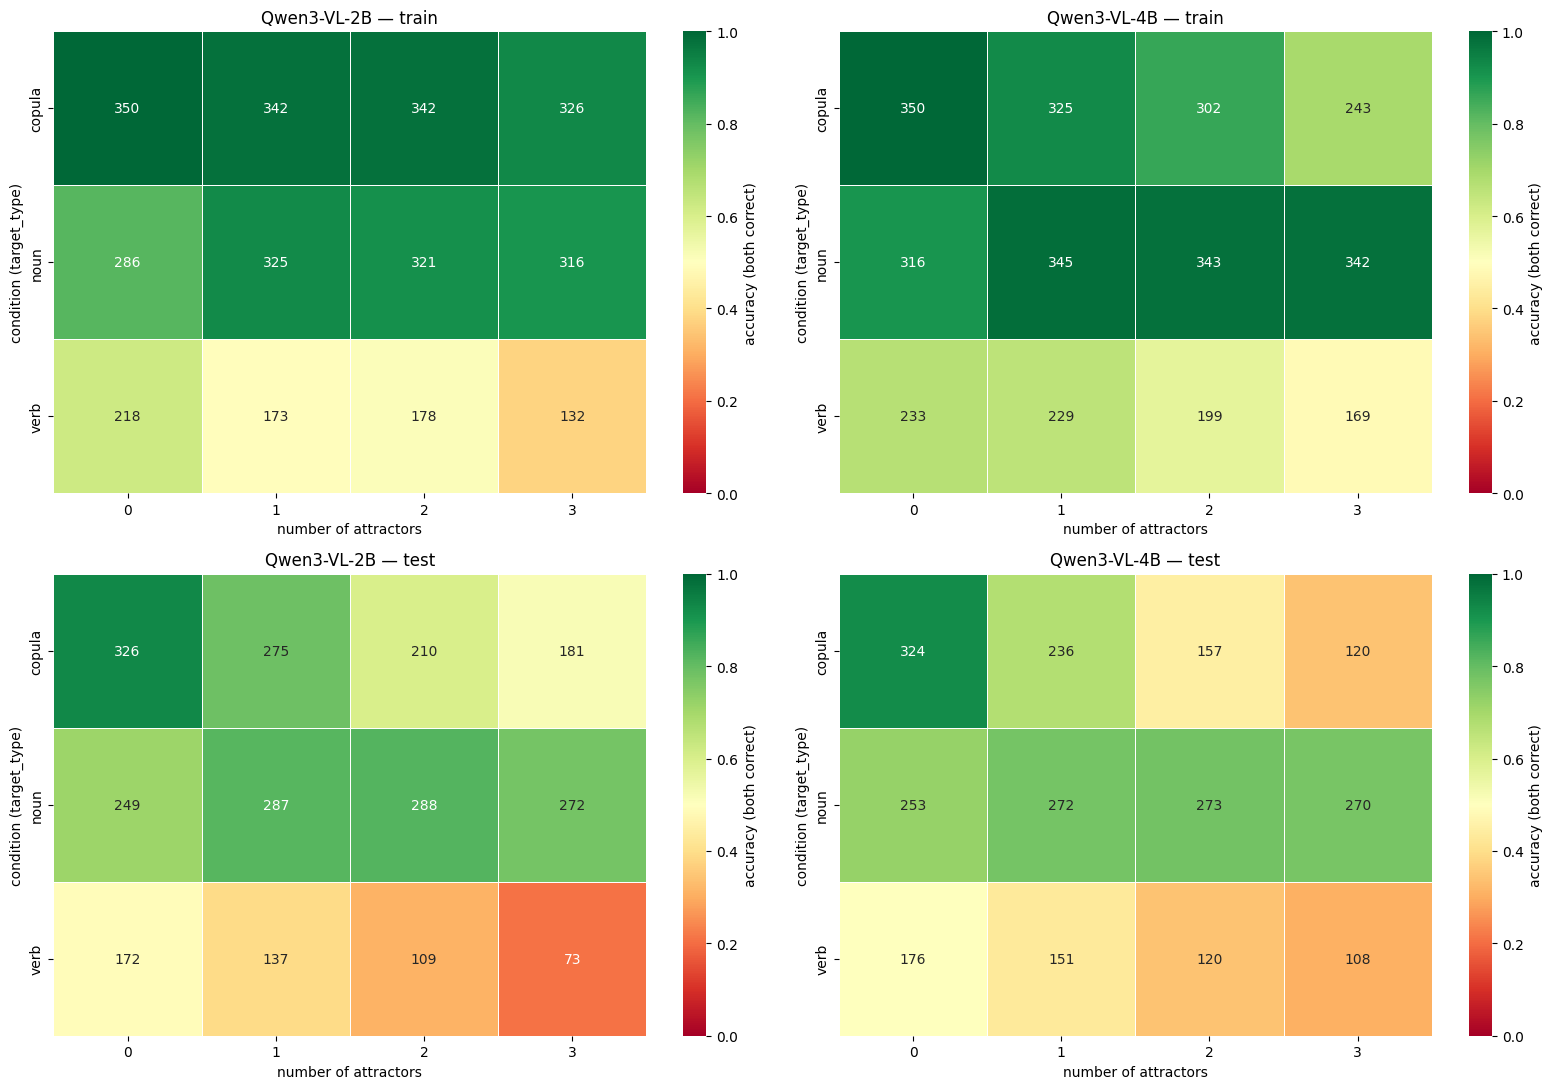

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

paths = {
    "Qwen3-VL-2B": "../../results/eval/interp/Qwen3-VL-2B-Instruct/agreement_target_natural_scored.csv",
    "Qwen3-VL-4B": "../../results/eval/interp/Qwen3-VL-4B-Instruct/agreement_target_natural_scored.csv",
}

splits = ["train", "test"]

fig, axes = plt.subplots(len(splits), len(paths), figsize=(16, 11))

for r, split in enumerate(splits):
    for c, (name, path) in enumerate(paths.items()):
        ax = axes[r, c]
        df = pd.read_csv(path)
        df = df[df["split"] == split]

        grp = df.groupby(["target_type", "attractors"])["is_correct_all"]
        prop  = grp.mean().unstack("attractors").sort_index()   # colors: P(both correct)
        count = grp.sum().unstack("attractors").sort_index()    # annotations: # both correct

        sns.heatmap(
            prop, ax=ax, annot=count, fmt=".0f",
            vmin=0, vmax=1, cmap="RdYlGn",
            cbar_kws={"label": "accuracy (both correct)"},
            linewidths=0.5, linecolor="white",
        )
        ax.set_title(f"{name} — {split}")
        ax.set_xlabel("number of attractors")
        ax.set_ylabel("condition (target_type)")

plt.tight_layout()
plt.show()

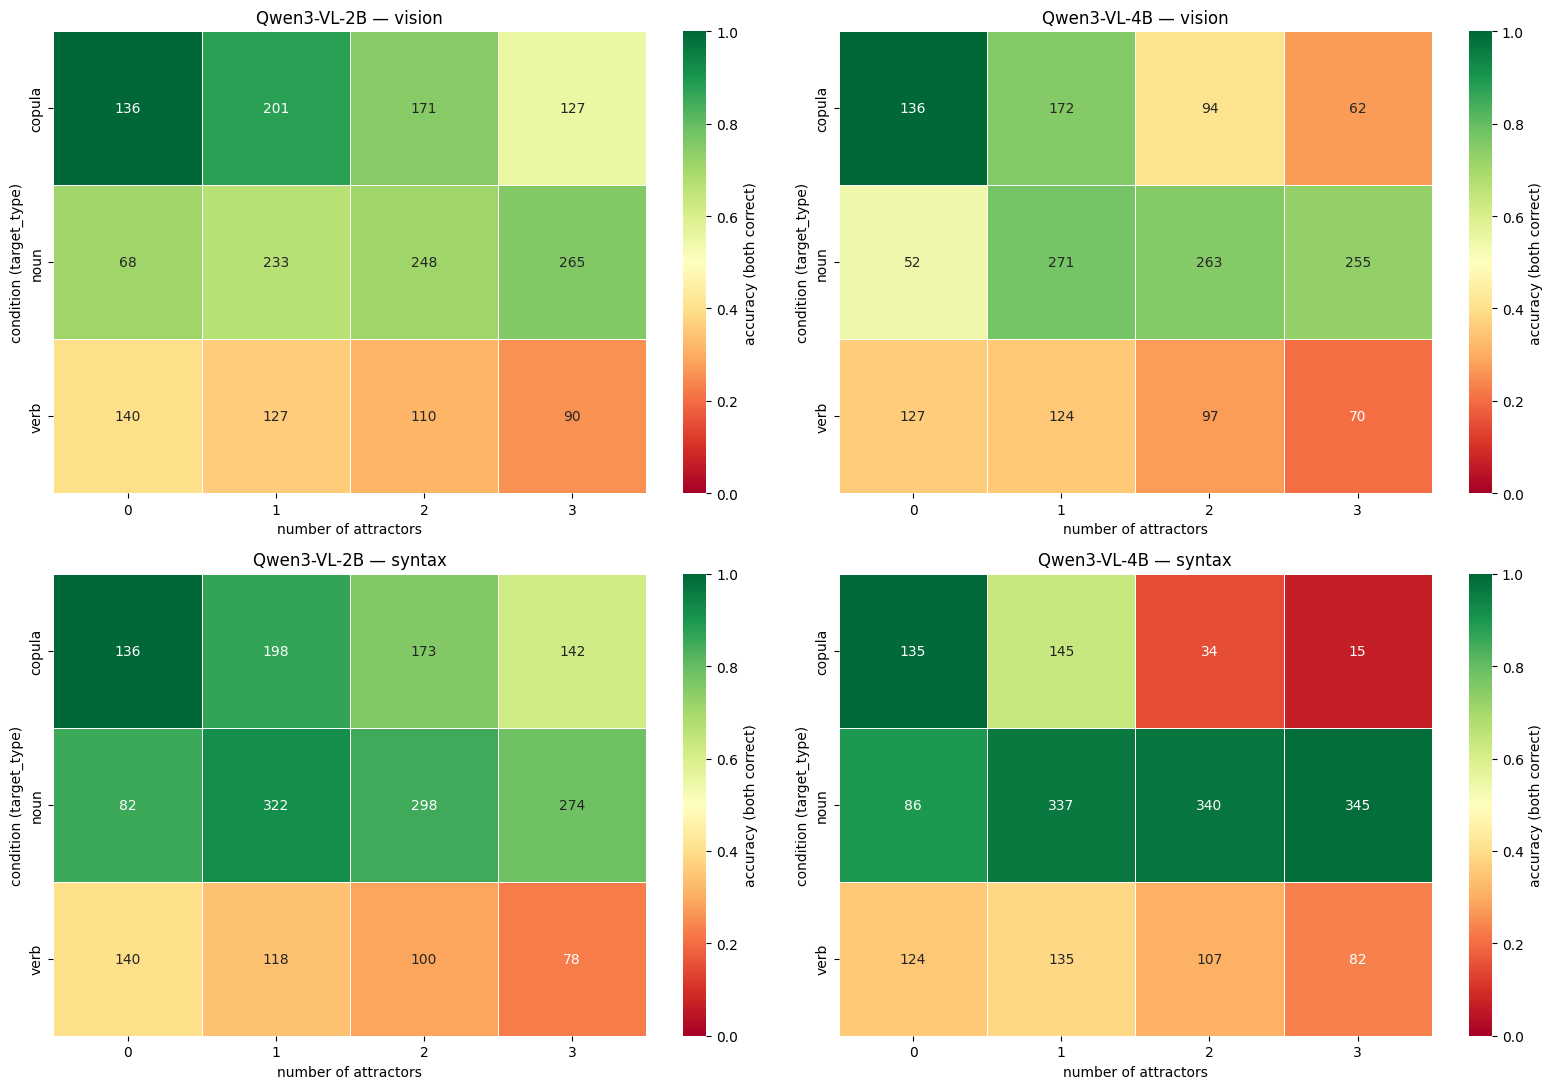

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Qwen3-VL-2B": "Qwen3-VL-2B-Instruct",
    "Qwen3-VL-4B": "Qwen3-VL-4B-Instruct",
}
embed_types = ["vision", "syntax"]

base = "../../results/eval/interp"
fname = "agreement_target_wug_scored.csv"

fig, axes = plt.subplots(len(embed_types), len(models), figsize=(16, 11))

for r, etype in enumerate(embed_types):
    for c, (name, model_dir) in enumerate(models.items()):
        ax = axes[r, c]
        path = f"{base}/{model_dir}/{etype}/{fname}"
        df = pd.read_csv(path)

        grp = df.groupby(["target_type", "attractors"])["is_correct_all"]
        prop  = grp.mean().unstack("attractors").sort_index()   # colors: P(both correct)
        count = grp.sum().unstack("attractors").sort_index()    # annotations: # both correct

        sns.heatmap(
            prop, ax=ax, annot=count, fmt=".0f",
            vmin=0, vmax=1, cmap="RdYlGn",
            cbar_kws={"label": "accuracy (both correct)"},
            linewidths=0.5, linecolor="white",
        )
        ax.set_title(f"{name} — {etype}")
        ax.set_xlabel("number of attractors")
        ax.set_ylabel("condition (target_type)")

plt.tight_layout()
plt.show()

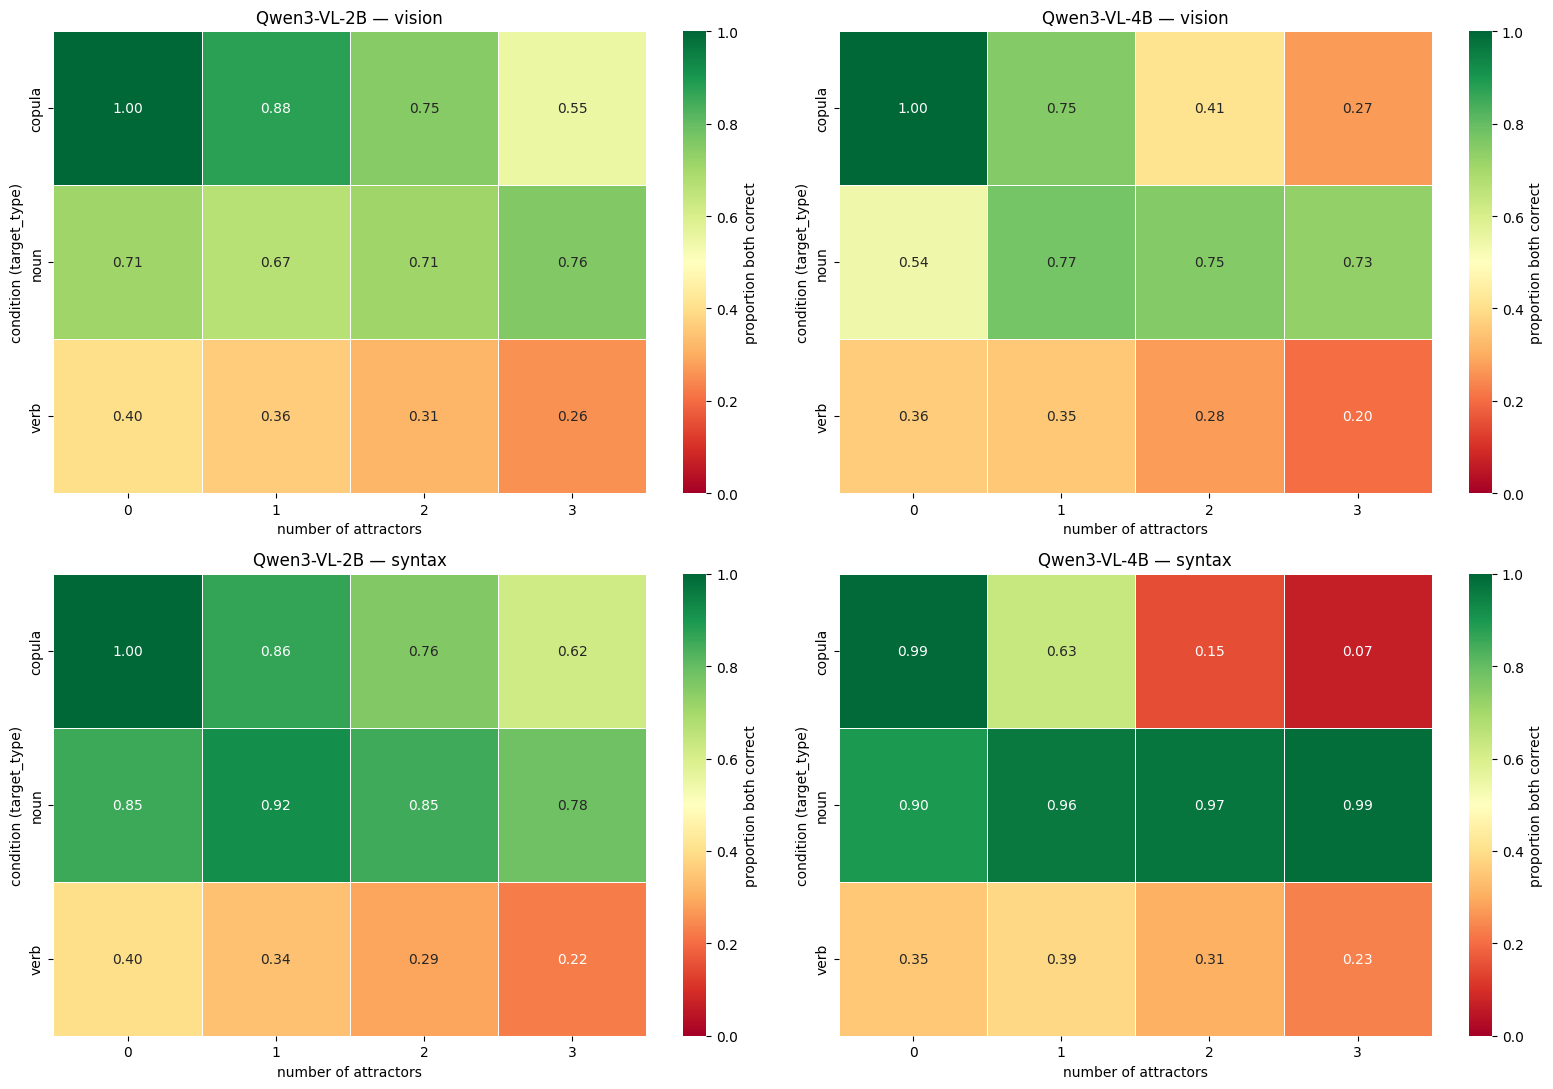

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Qwen3-VL-2B": "Qwen3-VL-2B-Instruct",
    "Qwen3-VL-4B": "Qwen3-VL-4B-Instruct",
}
embed_types = ["vision", "syntax"]

base = "../../results/eval/interp"
fname = "agreement_target_wug_scored.csv"

fig, axes = plt.subplots(len(embed_types), len(models), figsize=(16, 11))

for r, etype in enumerate(embed_types):
    for c, (name, model_dir) in enumerate(models.items()):
        ax = axes[r, c]
        path = f"{base}/{model_dir}/{etype}/{fname}"
        df = pd.read_csv(path)

        prop = (
            df.groupby(["target_type", "attractors"])["is_correct_all"]
            .mean().unstack("attractors").sort_index()   # proportion both correct
        )

        sns.heatmap(
            prop, ax=ax, annot=True, fmt=".2f",
            vmin=0, vmax=1, cmap="RdYlGn",
            cbar_kws={"label": "proportion both correct"},
            linewidths=0.5, linecolor="white",
        )
        ax.set_title(f"{name} — {etype}")
        ax.set_xlabel("number of attractors")
        ax.set_ylabel("condition (target_type)")

plt.tight_layout()
plt.show()